In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# Function definitions for a single-layer neural network using sigmoid as the activation function.
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Sigmoid of a linear transformation
def sig_ab(a, b, xi):
    return sigmoid(a*xi + b)

# Derivative of sig_ab with respect to a
def sig_dif_a(a, b, xi):
    return xi * sig_dif_b(a, b, xi)

# Derivative of sig_ab with respect ot b
def sig_dif_b(a, b, xi):
    return np.exp(-a*xi - b) / ((1 + np.exp(-a*xi - b))**2)

# Function call to evaluate the neural network
# w = [a0, b0, c0, a1, b1, c1, a2, b2, c2, c3]
#       0   1   2   3   4   5   6   7   8   9
def M(xi, w):
    s = 0

    # Evaluate the three hidden nodes
    for i in range(3):
        s += w[i+2] * sig_ab(w[i], w[i+1], xi)
    
    # Add final bias term
    s += w[9]

    return s

def mse_loss(xi, yi, w):
    return ((yi - M(xi, w))**2).sum()

# Gradient of our single layer neural network.
# w = [a0, b0, c0, a1, b1, c1, a2, b2, c2, c3]
#       0   1   2   3   4   5   6   7   8   9
def grad_mse(xi, yi, w):
    if isinstance(xi, np.ndarray):
        grad = np.zeros((w.shape[0], xi.shape[0]))
    else:
        grad = np.zeros_like(w)
    
    for i in range(3):
        # Partial derivatives with respect to a_i
        grad[i*3] = 2 * (yi - M(xi, w)) * -w[i*3+2] * sig_dif_a(w[i*3], w[i*3+1], xi)

        # Partial derivatives with respect to b_i
        grad[i*3+1] = 2 * (yi - M(xi, w)) * -w[i*3+2] * sig_dif_b(w[i*3], w[i*3+1], xi)
        
        # Partial derivatives with respect to c_i
        grad[i*3+2] = 2 * (yi - M(xi, w)) * -1 * sig_ab(w[i*3], w[i*3+1], xi)

    # Final partial - with respect to c_3
    grad[9] = 2 * (yi - M(xi, w)) * -1

    return grad

# Visualize loss
def visualize_loss(l_vect):
    plt.semilogy(np.arange(len(l_vect)), l_vect)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.show()

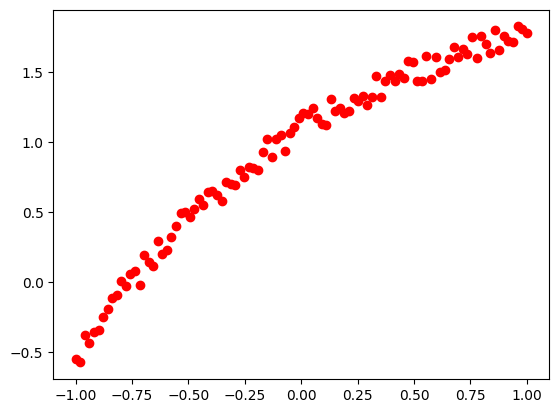

In [10]:
# Data to be trained on - let's have it fit to a noisy curve
np.random.seed(40)

f = lambda x: np.exp(x) - x**2
noise_scale = 0.2

x = np.linspace(-1, 1, 100)
y = f(x) + np.random.random(x.shape[0]) * noise_scale

plt.plot(x, y, "ro")
plt.show()

In [11]:
w_start = np.random.random(10)

In [14]:
# Adam Optimization
epochs = 500
batch_size = 8
lr = 0.001
beta_1 = 0.9
beta_2 = 0.999
l_vect = []

decay = 0.001

w = w_start.copy()

mean_moment = 0
var_moment = 0
t = 1
eps = 1e-8

for i in range(epochs):
    epoch_loss = 0
    
    # Stores an array of shuffled indices - useful for slicing
    shuffle = np.arange(len(x))
    np.random.shuffle(shuffle)

    num_batch = len(x) // batch_size
    if len(x) % batch_size != 0:
        num_batch += 1

    for b in range(num_batch):
        x_batch = x[shuffle][b*batch_size:(b+1)*batch_size]
        y_batch = y[shuffle][b*batch_size:(b+1)*batch_size]

        epoch_loss += mse_loss(x_batch, y_batch, w)
        grad = 1 / len(x_batch) * grad_mse(x_batch, y_batch, w).sum(axis=1)

        mean_moment = beta_1 * mean_moment + (1-beta_1) * grad
        var_moment = beta_2 * var_moment + (1-beta_2) * (grad**2)

        corrected_mean = mean_moment / (1 - beta_1**t)
        corrected_var = var_moment / (1 - beta_2**t)

        w -= lr * corrected_mean / (np.sqrt(corrected_var) + eps)

        t += 1

    l_vect.append(epoch_loss)

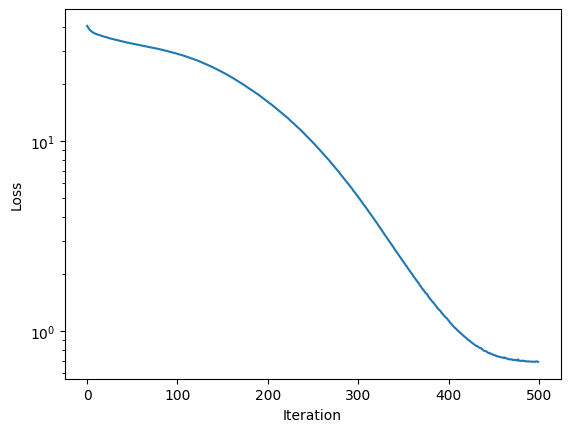

In [16]:
visualize_loss(l_vect)

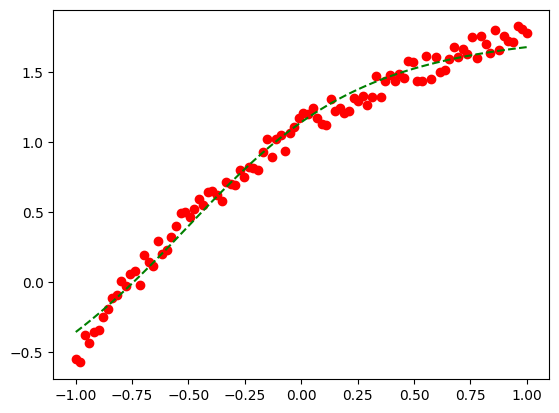

In [17]:
plt.plot(x, y, "ro", x, M(x, w), "g--");